# 08 — Producción: del anuncio en vivo al precio actual



Este notebook aplica el candidato de producción de `07` a anuncios de venta de Madrid
ciudad descargados de la API de idealista. El recorrido tiene tres pasos, y cada uno
arrastra una decisión que conviene no perder de vista:

1. **Descarga (§1).** La API tiene cuota. Cada respuesta se guarda en
   `data/api_idealista/` y el notebook solo llama a la API si falta esa copia y
   `LLAMAR_API = True`. Se ha dejado una *run* guardada. Las credenciales se leen de las variables de entorno
   `IDEALISTA_API_KEY` e `IDEALISTA_API_SECRET` y nunca se escriben en el notebook.
2. **Construcción de variables (§2).** Cada una de las 21 variables se reconstruye como en
   los datos de 2018 y, donde se puede, se comprueba contra ellos. Siete instalaciones no
   vienen en la respuesta de la API y se leen del texto del anuncio.
3. **Predicción y traslado a precios actuales (§3).** El modelo aprendió precios anunciados
   de 2018. Su predicción se lleva a **2026**, el año de los anuncios, con el índice de venta
   del distrito, y se convierte en renta mensual con el factor venta→renta del distrito en
   2026 (`src/indices_precio.py`). Ninguna serie llega a 2026: la venta registral acaba en
   2025 y el alquiler en 2024. Las dos se **proyectan** con la tendencia de cada distrito
   desde 2018 (§3.1).

In [12]:
import json, os, sys, warnings
from pathlib import Path

RAIZ = Path.cwd()
while not (RAIZ / "src").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
os.chdir(RAIZ); sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import produccion as prod, rutas
from src.amenidades_descripcion import AMENIDADES_API_NO_DEVUELVE, extraer_amenidades
from src.indices_precio import cargar_serie_venta, construir_indices

pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170); pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

# Con la caché ya descargada no se vuelve a llamar a la API aunque esté a True.
LLAMAR_API = True
DIR_CACHE = rutas.API_IDEALISTA
DIR_MODELOS = rutas.MODELOS
PROCESADOS = rutas.PROCESADOS

# Año al que se llevan venta, alquiler y factor venta→renta. Las series que no llegan se proyectan
# desde su último dato con la tendencia log-lineal desde ANO_INICIO_TENDENCIA.
ANO_ACTUAL = 2026
ANO_INICIO_TENDENCIA = 2018

# Muestra aleatoria: 10 páginas de 50 elegidas al azar (semilla fija) entre todas las del resultado,
# en vez de las 10 primeras. El orden por fecha de publicación es estable entre peticiones, así que
# las páginas no se solapan; el orden por defecto pone primero los destacados.
BUSQUEDA = {
    "country": "es", "operation": "sale", "property_type": "homes",
    "location_id": prod.LOCATION_ID_MADRID,
    "order": "publicationDate", "sort": "desc",
    "max_items_per_page": 50, "paginas_aleatorias": 10, "semilla": 0,
}
NOMBRE_BUSQUEDA = "madrid_ciudad_venta_aleatoria"

cliente = (prod.cliente_api_desde_entorno()
           if LLAMAR_API and not (DIR_CACHE / f"{NOMBRE_BUSQUEDA}.json").exists() else None)

## 1. Anuncios de Madrid ciudad

Búsqueda de viviendas en venta con `locationId` de Madrid municipio
(`0-EU-ES-28-07-001-079`), no de la provincia: las variables de barrio solo existen para
la ciudad.

**Muestra aleatoria.** La API no ordena al azar, así que se eligen páginas al azar: se pide la
página 1 para saber cuántas hay y se descargan 10 páginas de 50 anuncios sorteadas entre todas
con semilla fija (`search_random_pages`), 11 peticiones en total. Los resultados se ordenan por
fecha de publicación, un orden estable entre peticiones para que las páginas no se solapen. La
primera descarga (`madrid_ciudad_venta.json`, 10 primeras páginas en el orden por defecto) era
casi toda de anuncios destacados de lujo y distritos centrales, con una mediana de 155 m²
frente a 82 m² en train; se conserva en la caché.

In [13]:
anuncios_crudos, meta = prod.buscar_con_cache(NOMBRE_BUSQUEDA, BUSQUEDA, DIR_CACHE, LLAMAR_API, cliente)
anuncios = pd.json_normalize(anuncios_crudos).drop_duplicates("propertyCode").reset_index(drop=True)

print(f"búsqueda: {meta['nombre']} | descarga: {meta['descargado']} | páginas: {meta.get('paginas')} | "
      f"anuncios únicos: {len(anuncios)}")
print("municipio:", anuncios["municipality"].value_counts().to_dict())
print("tipología:", anuncios["propertyType"].value_counts().to_dict())
print(f"superficie: mediana {anuncios['size'].median():.0f} m² | p90 {anuncios['size'].quantile(0.9):.0f} m² | "
      f"máx {anuncios['size'].max():.0f} m²")
print(f"precio anunciado: mediana {anuncios['price'].median():,.0f} € | "
      f"rango [{anuncios['price'].min():,.0f}, {anuncios['price'].max():,.0f}] €")

búsqueda: madrid_ciudad_venta_aleatoria | descarga: 2026-09-15T22:09:18 | páginas: [21, 133, 156, 184, 198, 208, 216, 245, 249, 262] | anuncios únicos: 500
municipio: {'Madrid': 500}
tipología: {'flat': 451, 'chalet': 17, 'duplex': 15, 'penthouse': 12, 'studio': 5}
superficie: mediana 93 m² | p90 201 m² | máx 900 m²
precio anunciado: mediana 550,000 € | rango [98,500, 9,000,000] €


## 2. Construcción de las variables del modelo

| variable | origen en el anuncio | cómo | comprobación |
|---|---|---|---|
| `CONSTRUCTEDAREA`, `ROOMNUMBER`, `BATHNUMBER` | `size`, `rooms`, `bathrooms` | directo | — |
| `FLOORCLEAN` | `floor` | número; `bj`/`en` → 0, `ss`/`st` → -1; sin dato → mediana de train | — |
| `HASLIFT` | `hasLift` | directo; si falta, descripción | — |
| `HASPARKINGSPACE` | `parkingSpace.hasParkingSpace` | directo; si falta, 0 | — |
| `ISDUPLEX`, `ISSTUDIO` | `detailedType.subTypology`, `propertyType` | `duplex` / `studio` | — |
| 7 instalaciones | `description` | reglas de texto (§2.4) | — |
| `DISTANCE_TO_*` | `latitude`, `longitude` | haversine a los puntos de idealista18 | §2.1 |
| `alq_mediana_eur_m2_barrio` | barrio (§2.2) | alquiler 2026 (proyectado desde 2024) llevado al nivel de 2018 | §2.3 |
| `delitos_per_10k_barrio`, `indice_vulnerabilidad` | barrio (§2.2) | valores de entrenamiento | §2.3 |

Primero, el modelo y lo que `07` guardó con él.

In [14]:
artefacto = joblib.load(DIR_MODELOS / "produccion.joblib")
modelo, columnas = artefacto["modelo"], artefacto["columnas"]
print(f"modelo: {artefacto['nombre']} ({artefacto['familia']}) | {len(columnas)} variables | entrenado {artefacto['entrenado']}")
print(f"test (07): rmse_log {artefacto['metricas_test']['rmse_log']:.4f} | "
      f"error % mediano {artefacto['metricas_test']['error_pct_mediano']:.1f}% | smearing {artefacto['smearing']:.4f}")
print(columnas)

modelo: arboles_desplegable_ajustado (xgboost) | 21 variables | entrenado 2026-09-15T20:10:09
test (07): rmse_log 0.1856 | error % mediano 9.3% | smearing 1.0168
['CONSTRUCTEDAREA', 'ROOMNUMBER', 'BATHNUMBER', 'HASTERRACE', 'HASLIFT', 'HASAIRCONDITIONING', 'HASPARKINGSPACE', 'HASBOXROOM', 'HASWARDROBE', 'HASSWIMMINGPOOL', 'HASDOORMAN', 'HASGARDEN', 'ISDUPLEX', 'ISSTUDIO', 'FLOORCLEAN', 'DISTANCE_TO_CITY_CENTER', 'DISTANCE_TO_METRO', 'DISTANCE_TO_CASTELLANA', 'alq_mediana_eur_m2_barrio', 'delitos_per_10k_barrio', 'indice_vulnerabilidad']


### 2.1 Distancias

Distancia de haversine a Puerta del Sol, a la estación de metro más cercana y al punto más
cercano del eje de la Castellana, con los puntos de `Madrid_POIS.rda` (idealista18). 

Comprobación reconstruyendo sobre el dataset de 2018: sobre 5.000 anuncios de 2018, la fórmula tiene que reproducir las
`DISTANCE_TO_*` que trae el dataset.

In [15]:
pois = prod.cargar_pois()
muestra = (prod.cargar_anuncios_2018(["ASSETID", "LATITUDE", "LONGITUDE", "DISTANCE_TO_CITY_CENTER",
                                      "DISTANCE_TO_METRO", "DISTANCE_TO_CASTELLANA"])
           .sample(5000, random_state=0))
recalculadas = prod.calcular_distancias(muestra["LATITUDE"], muestra["LONGITUDE"], pois)

comprobacion = {}
for columna in recalculadas.columns:
    error_m = 1000 * np.abs(recalculadas[columna].to_numpy() - muestra[columna].to_numpy())
    comprobacion[columna] = {
        "error mediano (m)": np.median(error_m), "error p95 (m)": np.quantile(error_m, 0.95),
        "anuncios con error > 50 m": int((error_m > 50).sum()),
        "correlación": np.corrcoef(recalculadas[columna], muestra[columna])[0, 1],
    }
print(pd.DataFrame(comprobacion).round(3).to_string())

                           DISTANCE_TO_CITY_CENTER  DISTANCE_TO_METRO  DISTANCE_TO_CASTELLANA
error mediano (m)                            4.654              0.368                   2.213
error p95 (m)                               10.246              1.275                   8.059
anuncios con error > 50 m                    1.000              1.000                   1.000
correlación                                  1.000              1.000                   1.000


### 2.2 Barrio

Los barrios se obtienen disolviendo el seccionado censal de 2018 con el mapeo
sección→barrio de 2026, directamente, sin reconstruir el mapeo inverso a 2018. Las pocas
secciones que ese mapeo no cubre dejan huecos; un punto que cae en uno se asigna al barrio
más cercano (hasta 500 m).

Comprobación: aplicado a los 75.469 anuncios de 2018, tiene que devolver el barrio con el
que se construyeron sus variables de entrenamiento.

In [16]:
barrios = prod.cargar_barrios()
print(f"barrios: {len(barrios)} | secciones de 2018 sin barrio en el mapeo 2026: {barrios.attrs['secciones_sin_barrio']}")

geo_2018 = (prod.cargar_anuncios_2018(["ASSETID", "LATITUDE", "LONGITUDE"])
            .merge(pd.read_parquet(rutas.RUTA_ASSET_DISTRITO), on="ASSETID"))
asignado = prod.asignar_barrio(geo_2018["LATITUDE"], geo_2018["LONGITUDE"], barrios)
print(f"anuncios de 2018: {len(geo_2018):,} | asignados por cercanía: {asignado['barrio_rescatado'].mean():.2%} | "
      f"sin barrio: {asignado['barrio_code'].isna().sum()}")
print(f"barrio igual al de entrenamiento: {np.mean(asignado['barrio_code'].to_numpy() == geo_2018['barrio_code'].to_numpy()):.2%}"
      f" | distrito igual: {np.mean(asignado['distrito_code'].to_numpy() == geo_2018['distrito_code'].to_numpy()):.2%}")

barrios: 131 | secciones de 2018 sin barrio en el mapeo 2026: 34
anuncios de 2018: 75,469 | asignados por cercanía: 0.78% | sin barrio: 0
barrio igual al de entrenamiento: 99.11% | distrito igual: 99.79%


### 2.3 Variables de barrio

**Alquiler.** El modelo aprendió `alq_mediana_eur_m2_barrio` a nivel de 2018. Meter el
alquiler de 2026 sin más haría que un piso pareciera estar en un barrio más caro de lo que
el modelo conoce, y parte de la subida de mercado entraría por esa variable antes de aplicar
el índice de venta, que la volvería a contar. Por eso:

`alquiler de producción = alquiler del barrio en 2026 ÷ índice de alquiler de la ciudad 2018→2026 × calibración`

- El alquiler de barrio se agrega desde las secciones del SERPAVI con media ponderada por nº
  de viviendas, usando el mapeo de 2026 directamente.
- **Proyección a 2026.** El fichero de secciones llega a 2024. El alquiler de cada barrio y
  el de la ciudad se extienden a 2026 con su tendencia log-lineal de 2018 a 2024 (la misma
  que usan los índices de §3.1); un barrio con menos de dos años con dato toma la de la
  ciudad.
- El **índice de ciudad** es la subida general de precios en el periodo. La proyección solo mueve la variable en los barrios cuyo
  alquiler sube más o menos deprisa que el de la ciudad: frente a usar 2024, el cambio
  mediano es del +0,4 % y solo 6 de 131 barrios se mueven más de un 3 %.
- La **calibración** corrige una diferencia de método: el agregado de entrenamiento se hizo
  con otro mapeo e imputación. Así, un barrio cuyo alquiler relativo no ha cambiado recibe
  el valor que vio el modelo. Es un único número para todos los barrios:

  $$\text{calibración} = \operatorname*{mediana}_{b \in B} \frac{E_b}{A_b^{2018}}, \qquad A_b^{t} = \frac{\sum_{s \in b} r_s^{t}\, v_s^{t}}{\sum_{s \in b} v_s^{t}}$$

  - $E_b$: valor de `alq_mediana_eur_m2_barrio` que vio el modelo en el barrio $b$
    (`valores_barrio_entrenamiento`).
  - $A_b^{t}$: alquiler del barrio $b$ en el año $t$ con el método de producción
    (`_alquiler_por_barrio`): media de las secciones censales $s$ que el mapeo de 2026 asigna
    a $b$, ponderada por viviendas.
  - $r_s^{t}$: renta mediana de vivienda colectiva de la sección (€/m²·mes, columna
    `Mediana.1` de la hoja del año); $v_s^{t}$: nº de viviendas en alquiler de la sección. Se
    descartan las secciones sin renta o sin viviendas.
  - $B$: barrios con valor en entrenamiento y en el agregado de 2018.

**Delitos y vulnerabilidad.** Los datos de entrenamiento ya se construyeron con las fuentes
actuales (incidencias de 2026, vulnerabilidad de 2020), así que se usan esos mismos valores.
Solo un barrio sin anuncios en entrenamiento (El Cañaveral) se calcula desde las fuentes.

In [17]:
tabla_barrio = prod.tabla_variables_barrio(ano_destino=ANO_ACTUAL, ano_inicio_tendencia=ANO_INICIO_TENDENCIA)
a = tabla_barrio.attrs
print(f"alquiler de la ciudad: {a['ano_base']} {a['alquiler_ciudad_base']:.2f} €/m²·mes -> {a['ano_destino']} "
      f"{a['alquiler_ciudad_destino']:.2f} (proyectado desde {a['ultimo_ano_alquiler']}) | índice {a['indice_alquiler_ciudad']:.4f} | "
      f"calibración de método {a['calibracion_metodo']:.4f}")

entrenamiento = prod.valores_barrio_entrenamiento()
alquileres = pd.DataFrame({
    "entrenamiento (2018)": entrenamiento["alq_mediana_eur_m2_barrio"],
    f"{a['ano_destino']} sin ajustar": tabla_barrio[f"alquiler_{a['ano_destino']}_crudo"],
    f"producción ({a['ano_destino']} al nivel de 2018)": tabla_barrio["alq_mediana_eur_m2_barrio"],
})
print("\n" + alquileres.describe().round(2).to_string())
comunes = alquileres.dropna()
print(f"\ncorrelación entrenamiento vs producción: {comunes.iloc[:, 0].corr(comunes.iloc[:, 2]):.3f}")
print(f"barrios por encima del máximo de entrenamiento: {(tabla_barrio['alq_mediana_eur_m2_barrio'] > entrenamiento['alq_mediana_eur_m2_barrio'].max()).sum()}")

cambio = (comunes.iloc[:, 2] / comunes.iloc[:, 0] - 1).sort_values()
print("\nbarrios cuyo alquiler relativo más ha bajado / subido desde 2018:")
print(pd.concat([cambio.head(5), cambio.tail(5)]).map("{:+.1%}".format).to_string())
print("\nbarrios con delitos y vulnerabilidad calculados desde fuentes:")
print(tabla_barrio[tabla_barrio["fuente_delitos_vulnerabilidad"] != "entrenamiento"].round(3).to_string())

  3 barrio(s) sin dato en 2018, cubiertos con 2019: 183, 193, 194
alquiler de la ciudad: 2018 11.40 €/m²·mes -> 2026 15.55 (proyectado desde 2024) | índice 1.3643 | calibración de método 0.9286

       entrenamiento (2018)  2026 sin ajustar  producción (2026 al nivel de 2018)
count                130.00            131.00                              131.00
mean                  10.24             15.31                               10.42
std                    1.93              3.02                                2.06
min                    6.71             10.11                                6.88
25%                    8.57             12.92                                8.79
50%                   10.08             14.70                               10.00
75%                   11.79             17.56                               11.95
max                   14.84             23.30                               15.86

correlación entrenamiento vs producción: 0.950
barrios por encima 

### 2.4 Instalaciones desde la descripción

Como la llamada a la API no provee con las variables de instalaciones, las sacamos de la descripción.
Reglas de `src/amenidades_descripcion.py`. Cada instalación queda en uno de cuatro estados:

- **mencionado**: la descripción la nombra ("terraza", "aire acondicionado", "trastero"…)
  sin que el contexto la anule;
- **negado**: el anuncio subraya que no la tiene ("sin ascensor");
- **sin mención**: no aparece;
- **sin descripción**: el anuncio no trae texto.

Solo "mencionado" cuenta como 1. El criterio es que son rasgos que suman valor y quien los
tiene tiende a anunciarlos, aunque no siempre lo hace. Las exclusiones evitan los falsos
positivos más frecuentes: terrazas de bares del barrio, "portero automático" (un
interfono), "Real Jardín Botánico" o "vistas al jardín", preinstalación de aire
acondicionado, garaje o trastero opcionales. Ascensor y garaje no se leen del texto: la API
los devuelve.

In [18]:
extraccion = anuncios["description"].map(extraer_amenidades)
estados = pd.DataFrame([{a: r[a]["estado"] for a in AMENIDADES_API_NO_DEVUELVE + ["HASLIFT"]} for r in extraccion])
print(estados.apply(pd.Series.value_counts).fillna(0).astype(int).T.to_string())

print("\nEjemplo de fragmento que justifica cada amenity:")
for amenidad in AMENIDADES_API_NO_DEVUELVE:
    evidencia = next((r[amenidad]["evidencia"] for r in extraccion if r[amenidad]["evidencia"]), None)
    print(f"  {amenidad:20s} ...{evidencia}...")
negaciones = [r["HASLIFT"]["negacion"] for r in extraccion if r["HASLIFT"]["negacion"]]
print(f"\nascensor negado en {len(negaciones)} anuncios; ejemplo: ...{negaciones[0] if negaciones else '—'}...")

                    mencionado  negado  sin_mencion
HASTERRACE                 199       0          301
HASAIRCONDITIONING         167       0          333
HASBOXROOM                 123       0          377
HASWARDROBE                123       0          377
HASSWIMMINGPOOL             91       0          409
HASDOORMAN                 120       3          377
HASGARDEN                   60       0          440
HASLIFT                    149      23          328

Ejemplo de fragmento que justifica cada amenity:
  HASTERRACE           ...talmente exterior con tres dormitorios y dos terrazas acristaladas. ponemos a la venta esta vivien...
  HASAIRCONDITIONING   ...io, puertas interiores de madera y equipo de aire acondicionado. aunque puede utilizarse desde el primer mom...
  HASBOXROOM           ...preinstalacion para cargador electrico y dos trasteros unidos en uno solo de 15 metros cuadrados. d...
  HASWARDROBE          ...os otros dos dormitorios disponen tambien de armarios empotra

### 2.5 Matriz de entrada

Se construye la matriz de variables extraídas de la API y se marcan los valores fuera del rango de train,
donde un modelo de árboles no extrapola.

También se marcan las viviendas de **obra nueva** (`obra_nueva`). Una promoción anuncia cada
vivienda por separado, así que sus errores no son independientes: se valoran igual, pero
cualquier agregado debería contar cada promoción una vez (§5).

In [19]:
X, contexto = prod.construir_variables(anuncios, columnas, tabla_barrio, pois, barrios, artefacto["mediana_planta_train"])
fuera = prod.fuera_de_rango(X, artefacto["rangos_train"])
contexto["fuera_de_rango"] = fuera.any(axis=1)

print(f"matriz: {X.shape} | planta imputada: {contexto['planta_imputada'].sum()} | "
      f"ascensor desde descripción: {contexto['ascensor_desde_descripcion'].sum()} | "
      f"barrio por cercanía: {contexto['barrio_rescatado'].sum()} | obra nueva: {contexto['obra_nueva'].sum()}")
print("fuera del rango de train:", fuera.sum()[fuera.sum() > 0].to_dict())

matriz: (500, 21) | planta imputada: 34 | ascensor desde descripción: 17 | barrio por cercanía: 5 | obra nueva: 33
fuera del rango de train: {'CONSTRUCTEDAREA': 1, 'FLOORCLEAN': 3, 'alq_mediana_eur_m2_barrio': 19}


## 3. Predicción y traslado a precios actuales

Notación: $d$ es el distrito del anuncio, $t$ el año, $V_{d,t}$ la venta registral (€/m²) y
$A_{d,t}$ el alquiler (€/m²·mes).

1. **Precio al nivel de 2018**. Es lo que el modelo sabe estimar: el precio anunciado
   (mínimo) que habría tenido una vivienda así en 2018. El valor específico de *smearing* se
   puede ver en el notebook 07, y está en el rango de 1-2%

   $$\hat P_{2018} = e^{\hat y} \cdot s$$

   con $\hat y$ la predicción del modelo en logaritmo y $s$ el factor de *smearing* de Duan.

2. **Precio de 2026**: × índice de venta de su distrito, 2018 → 2026. Se usa el distrito y no
   el barrio porque en algunos barrios la materialidad era muy baja. El valor de 2026 es una
   proyección (§3.1).

   $$\hat P_{2026} = \hat P_{2018} \cdot I_d, \qquad I_d = \frac{V_{d,2026}}{V_{d,2018}}, \qquad V_{d,2026} = V_{d,2025}\,\bigl(1 + g^{V}_d\bigr)$$

3. **Renta mensual estimada**: precio de 2026 × factor venta→renta del distrito en 2026.

   $$\hat R_{2026} = \hat P_{2026} \cdot f_d, \qquad f_d = \frac{A_{d,2026}}{V_{d,2026}}, \qquad A_{d,2026} = A^{\text{oficial}}_{d,2024}\,\bigl(1 + g^{A}_d\bigr)^{2}$$

   Sustituyendo, $\hat R_{2026} = \hat P_{2018} \cdot A_{d,2026} / V_{d,2018}$: la proyección de
   la venta se cancela y la renta estimada solo depende de la proyección del alquiler.



**Tasas de tendencia.** $g^{V}_d$ y $g^{A}_d$ son la tasa anual de la tendencia log-lineal de
cada distrito desde 2018 (`crecimiento_tendencia`):

$$g_d = e^{\beta_d} - 1, \qquad (\alpha_d, \beta_d) = \arg\min_{\alpha,\,\beta} \sum_{t=2018}^{T} \bigl(\ln X_{d,t} - \alpha - \beta\, t\bigr)^2$$

- Venta: $X_{d,t} = V_{d,t}$ y $T = 2025$.
- Alquiler: $X_{d,t} = \tilde A_{d,t}$ y $T = 2024$, donde $\tilde A_{d,t}$ es el alquiler del
  distrito agregado desde las secciones censales $s$ (renta mediana $r_{s,t}$, ponderada por
  el nº de viviendas en alquiler $v_{s,t}$):
  $$\tilde A_{d,t} = \frac{\sum_{s \in d} r_{s,t}\, v_{s,t}}{\sum_{s \in d} v_{s,t}}$$
  La tasa se toma de $\tilde A$ porque el fichero oficial de distrito solo trae 2024, pero el
  nivel de partida es el oficial, $A^{\text{oficial}}_{d,2024}$.

**Anuncios que no se valoran** (`fuera_de_dominio`, precio a NaN), además de los que no
tienen barrio:

- **Chalets y casas.** El modelo no tiene variable de parcela ni de vivienda unifamiliar. En
  la descarga aleatoria del 2026-09-15 (17 casos) su `anunciado / estimado` es muy disperso:
  la mediana queda cerca de lo típico (−5 %), pero un 35 % quedaría como "sobrevalorado", más
  de un 20 % por encima. El error es del modelo, no del anuncio.
- **Superficie por encima del percentil 99 de train.** Apenas hay viviendas así en train y
  un modelo de árboles no extrapola: devuelve lo mismo que en el extremo.
- **A reformar** (`a_reformar`). El modelo no ve el estado de conservación: una vivienda a
  reformar pide menos por el coste de la obra y saldría "infravalorada" sin serlo. Se detecta
  en la descripción ("a reformar", "para reformar", "para actualizar", "necesita reforma"…),
  salvo que diga "sin necesidad de reformar" o similar. Las viviendas ya reformadas sí se
  valoran.
- **Ocupada o alquilada** (`ocupada`). Una vivienda con ocupantes, inquilino o sin posesión se
  vende con un descuento que el modelo tampoco ve. Se detecta en la descripción ("ocupada",
  "okupada", "sin posesión", "nuda propiedad", "usufructo", "renta antigua", "con inquilinos",
  "se encuentra alquilada"…), salvo que diga "libre de inquilinos" o similar. La mención de
  "nuda propiedad" en la lista de servicios del pie de algunas agencias no cuenta.

Las reglas de texto están en `produccion.PATRON_A_REFORMAR` y `produccion.PATRON_OCUPADA`.

La columna `anunciado / estimado` compara el precio pedido hoy con la estimación. No se
espera que sea 1: el índice es de precio de cierre y el modelo, de precio anunciado, el
último año del índice es una proyección y el propio error del modelo está en §4 de `07`.

### 3.1 Proyección de los índices a 2026

`construir_indices` devuelve directamente los valores de 2026 con las fórmulas de arriba.
Usar todos los años de la ventana en la tendencia, y no solo el primero y el último, suaviza
los saltos de un año concreto:

- **Venta**: mediana entre distritos de $g^{V}_d$, +6,4 % anual.
- **Alquiler**: $\tilde A$ queda a 1-3 % del nivel oficial (misma fuente, SERPAVI). Mediana de
  $g^{A}_d$, +3,8 % anual. Se exporta por anuncio como `alquiler_distrito_eur_m2_2026`.
- **Factor venta→renta 2026**: como la venta sube más deprisa que el alquiler, $f_d$ baja
  respecto a 2024 (la rentabilidad bruta mediana, $1200 \cdot f_d$, cae en torno a un 15 %).

La ventana empieza en 2018, el año base del modelo: antes de 2014 la serie de venta recoge
la caída posterior a 2008 y rebajaría la tendencia a la mitad.

In [20]:
indices = construir_indices(ano_destino=ANO_ACTUAL, ano_renta=ANO_ACTUAL, ano_inicio_tendencia=ANO_INICIO_TENDENCIA)
ANO_PRECIO, ANO_RENTA = indices.attrs["ano_destino"], indices.attrs["ano_renta"]
nombres_distrito = indices.set_index("distrito_code")["distrito"]
AREA_MAX_DOMINIO = pd.read_parquet(PROCESADOS / f"X_train_{artefacto['dataset']}.parquet")["CONSTRUCTEDAREA"].quantile(0.99)
precio_2018 = prod.predecir_precio_base(modelo, X, artefacto["smearing"])
ajuste = prod.ajustar_precio(precio_2018, contexto["distrito_code"], indices)
# Excluir inmuebles fuera de dominio: chalet o casa, superficie > p99 de train, a reformar, ocupada o alquilada
dominio = prod.motivos_fuera_de_dominio(anuncios, X, AREA_MAX_DOMINIO)

resultado = pd.concat([
    contexto,
    X[["CONSTRUCTEDAREA", "ROOMNUMBER", "BATHNUMBER"]],
    pd.DataFrame({"precio_estimado_2018": precio_2018}),
    ajuste,
    dominio,
], axis=1).rename(columns={"precio_estimado_destino": "precio_estimado"})
resultado["fuera_de_dominio"] = dominio.any(axis=1)
no_valorados = resultado["sin_barrio"] | resultado["fuera_de_dominio"]
resultado.loc[no_valorados, ["precio_estimado_2018", "precio_estimado", "renta_mensual_estimada"]] = np.nan
resultado["distrito"] = resultado["distrito_code"].map(nombres_distrito)
resultado[f"alquiler_distrito_eur_m2_{ANO_RENTA}"] = resultado["distrito_code"].map(
    indices.set_index("distrito_code")[f"alquiler_{ANO_RENTA}"])
resultado["anunciado / estimado"] = resultado["precio_anunciado"] / resultado["precio_estimado"]

i = indices.attrs
print(f"venta, alquiler y factor de {ANO_PRECIO} | proyectados desde venta {i['ultimo_ano_venta']} y alquiler "
      f"{i['ultimo_ano_alquiler']} con la tendencia desde {i['ano_inicio_tendencia']}")
print(f"tendencia anual (mediana entre distritos): venta {indices['crecimiento_venta_anual'].median():+.1%} | "
      f"alquiler {indices['crecimiento_alquiler_anual'].median():+.1%} | "
      f"rentabilidad bruta mediana {ANO_RENTA}: {indices['rentabilidad_bruta_pct'].median():.2f} %")
print(f"índice de venta de la ciudad 2018->{ANO_PRECIO}: {i['indice_venta_ciudad']:.3f}")
print(f"no valorados: {int(no_valorados.sum())} de {len(resultado)} | chalet o casa: {int(dominio['tipologia_casa'].sum())} | "
      f"superficie > p99 de train ({AREA_MAX_DOMINIO:.0f} m²): {int(dominio['superficie_fuera_de_dominio'].sum())} | "
      f"a reformar: {int(dominio['a_reformar'].sum())} | ocupada o alquilada: {int(dominio['ocupada'].sum())} | "
      f"sin barrio: {int(resultado['sin_barrio'].sum())}")
print(f"anunciado / estimado: mediana {resultado['anunciado / estimado'].median():.3f} | "
      f"p25 {resultado['anunciado / estimado'].quantile(0.25):.3f} | p75 {resultado['anunciado / estimado'].quantile(0.75):.3f}")

vista = ["propertyCode", "distrito", "CONSTRUCTEDAREA", "ROOMNUMBER", "precio_anunciado", "precio_estimado_2018",
         "indice_venta", "precio_estimado", "renta_mensual_estimada", f"alquiler_distrito_eur_m2_{ANO_RENTA}",
         "anunciado / estimado"]
print("\n" + resultado[vista].head(10).round(2).to_string(index=False))

venta, alquiler y factor de 2026 | proyectados desde venta 2025 y alquiler 2024 con la tendencia desde 2018
tendencia anual (mediana entre distritos): venta +6.4% | alquiler +3.8% | rentabilidad bruta mediana 2026: 3.45 %
índice de venta de la ciudad 2018->2026: 1.745
no valorados: 88 de 500 | chalet o casa: 17 | superficie > p99 de train (367 m²): 12 | a reformar: 35 | ocupada o alquilada: 36 | sin barrio: 0
anunciado / estimado: mediana 1.003 | p25 0.871 | p75 1.137

propertyCode            distrito  CONSTRUCTEDAREA  ROOMNUMBER  precio_anunciado  precio_estimado_2018  indice_venta  precio_estimado  renta_mensual_estimada  alquiler_distrito_eur_m2_2026  anunciado / estimado
   112480781           Salamanca            226.0           4         1900000.0                   NaN          1.88              NaN                     NaN                          19.77                   NaN
   112523989           Vicálvaro             80.0           3          198000.0         145265.421875     

                     anuncios  precio_anunciado_mediano  estimado_mediano  renta_mensual_mediana  anunciado_sobre_estimado
distrito                                                                                                                  
Centro                     63                  700000.0         744827.98                1881.74                      0.97
Salamanca                  50                 1347500.0        1300466.10                2537.58                      1.04
Chamberí                   40                  962500.0         987247.83                2249.68                      0.96
Puente de Vallecas         25                  249000.0         240023.42                 952.36                      1.02
Tetuán                     24                  450000.0         485306.32                1445.45                      0.91
Ciudad Lineal              21                  385000.0         334014.25                 959.24                      1.14
Villaverde      

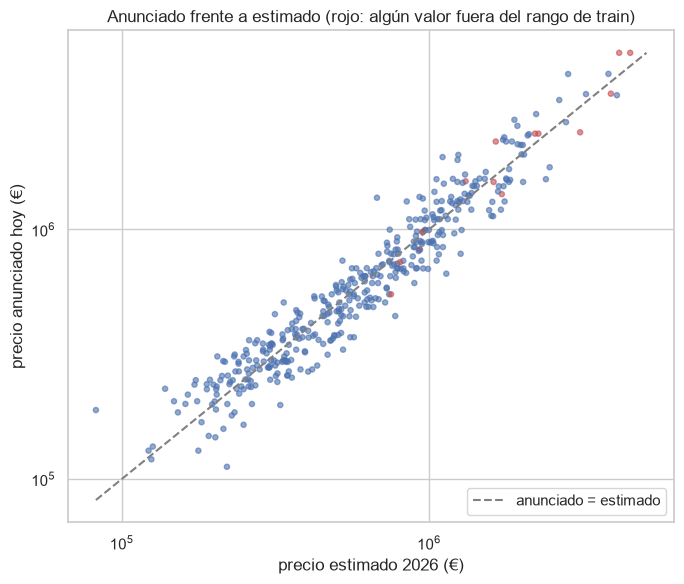

error absoluto % frente al anunciado: mediana 12.9 % (MAPE 16.7 %) en esta descarga | mediana 9.3 % (MAPE 13.6 %) en test 2018


In [21]:
por_distrito = (resultado.dropna(subset=["precio_estimado"])
                .groupby("distrito")
                .agg(anuncios=("propertyCode", "size"),
                     precio_anunciado_mediano=("precio_anunciado", "median"),
                     estimado_mediano=("precio_estimado", "median"),
                     renta_mensual_mediana=("renta_mensual_estimada", "median"),
                     anunciado_sobre_estimado=("anunciado / estimado", "median"))
                .sort_values("anuncios", ascending=False))
print(por_distrito.round(2).to_string())

validos = resultado.dropna(subset=["precio_estimado"])
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(validos["precio_estimado"], validos["precio_anunciado"], s=14, alpha=0.6,
           c=np.where(validos["fuera_de_rango"], "#C44E52", "#4C72B0"))
limites = [validos[["precio_estimado", "precio_anunciado"]].min().min(),
           validos[["precio_estimado", "precio_anunciado"]].max().max()]
ax.plot(limites, limites, color="gray", linestyle="--", label="anunciado = estimado")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(f"precio estimado {ANO_PRECIO} (€)"); ax.set_ylabel("precio anunciado hoy (€)")
ax.set_title("Anunciado frente a estimado (rojo: algún valor fuera del rango de train)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Error frente al precio anunciado, en los anuncios valorados, y referencia del test de 2018 (07). No
# es una comparación limpia: el test no excluye chalets, a reformar u ocupadas como esta descarga (§3).
error_pct = (validos["precio_anunciado"] - validos["precio_estimado"]).abs() / validos["precio_anunciado"]
mdape_test, mape_test = artefacto["metricas_test"]["error_pct_mediano"], artefacto["metricas_test"]["error_pct_medio"]
mdape_desc, mape_desc = error_pct.median() * 100, error_pct.mean() * 100
print(f"error absoluto % frente al anunciado: mediana {mdape_desc:.1f} % (MAPE {mape_desc:.1f} %) en esta descarga "
      f"| mediana {mdape_test:.1f} % (MAPE {mape_test:.1f} %) en test 2018")

Vemos que el error es algo mayor (sobre una sample de ~400 inmuebles) que en el conjunto test de 2018. Este incremento del error es comprensible dadas las limitaciones que presenta la API, así como el hecho de que el *core* del modelo está entrenado en 2018 y las limitaciones que han sido comentadas a lo largo de este notebook.

## 4. Exportación

In [22]:
salida = DIR_CACHE / f"predicciones_{meta['descargado'][:10]}.csv"
salida.parent.mkdir(parents=True, exist_ok=True)
resultado.to_csv(salida, index=False)
print(f"{len(resultado)} anuncios -> {salida}")

500 anuncios -> C:\Users\tomas\Documents\Master\habitia-madrid\data\api_idealista\predicciones_2026-09-15.csv


## 5. Límites

Las cifras de esta sección salen de la descarga aleatoria del 2026-09-15: 500 anuncios de 10
páginas sorteadas entre las 325 del resultado (§1), de los que se valoran 412. Se parece más
al mercado que la primera descarga, casi toda de destacados "Top+": aquí 315 anuncios no
están destacados y aparecen los 21 distritos. Aun así son 500 anuncios, así que sirven para
identificar los límites y su orden de magnitud, no para medirlos con precisión. La desviación
de un anuncio es su `anunciado / estimado` respecto a la mediana de la descarga (1,003); los
efectos citados salen de una regresión conjunta de esa desviación sobre las características
del anuncio, controlando por distrito, con el estadístico $t$ entre paréntesis.

### Qué no se valora

- **Chalets y casas**, **superficies por encima del percentil 99 de train** y viviendas **a
  reformar** u **ocupadas o alquiladas** (§3).
- **Estado y ocupación no mencionados.** Las dos últimas exclusiones solo funcionan si la
  descripción lo dice. Una vivienda a reformar u ocupada que no lo menciona se valora igual y
  sale infravalorada. La anulación ("libre de inquilinos", "sin necesidad de reformar") se
  busca en toda la descripción, no junto a la mención.
- **Lo que no es una vivienda.** Solares, lotes de varias viviendas y edificios completos
  pueden aparecer en la búsqueda como `flat` o `chalet`, y el modelo los valora como si fueran
  una sola vivienda. Detectarlos por el texto del anuncio no es fiable, así que no se filtran:
  hay que revisarlos a mano.
- **Duplicados.** El mismo inmueble anunciado por varias agencias aparece varias veces y
  recibe la misma estimación. No afecta a la valoración de cada anuncio, pero hay que
  deduplicar antes de cualquier estadística agregada.

### Qué no ve el modelo

Ninguno tiene una corrección directa: los datos de 2018 no traen estas variables.

- **Ático y vistas.** Los áticos piden en torno a un 12 % más de lo estimado, con solo 9
  anuncios valorados. Mencionar vistas no se separa de lo típico (+2 %).
- **Obra nueva y promociones** (`obra_nueva`). Las 33 viviendas de obra nueva piden un 9 %
  menos de lo estimado, pero no son casos independientes: una promoción anuncia
  cada vivienda por separado, así que varias unidades comparten el mismo error. Además, las
  promociones en desarrollos urbanísticos posteriores a 2018 quedan asignadas a barrios
  antiguos, y el modelo las valora con datos de un entorno que no las describe. Se valoran
  igual, pero marcadas, y cualquier agregado debería contar cada promoción una vez.
- **Estado no declarado en el texto.** Las 44 viviendas valoradas que la API marca con
  `status = renew` pero cuya descripción no dice que estén a reformar piden un 5 % menos
  ($t$ = −1,5).
- **Motivación del vendedor.** Ni la bajada de precio (−2 %, 67 anuncios) ni hablar de
  inversión o rentabilidad (−1 %, 144 anuncios) se separan de lo típico en esta muestra. Las
  viviendas que dicen estar alquiladas u ocupadas ya se excluyen (§3).

### Ruido y sesgo del modelo

- **Ruido.** En test, el 19 % de las viviendas queda a más de ±20 % de su precio real.
- **Sesgo por nivel de precio (07).** El modelo sobrestima las viviendas más baratas (+8 %
  en el quintil inferior de test) e infraestima las más caras (−2 % en el superior).

### Traslado a precios actuales

- **Qué predice el modelo.** El precio anunciado mínimo de 2018 por inmueble, no el de
  cierre. El índice de venta es de precio de cierre: trasladar con él supone que la
  distancia entre precio anunciado y de cierre no ha cambiado desde 2018.
- **2026 es una proyección, no un dato.** Venta, alquiler y factor venta→renta de 2026 salen
  de la tendencia de cada distrito desde 2018 (§3.1). Una tendencia larga es estable pero
  lenta: la de venta es de un +6 % anual, cuando de 2024 a 2025 la venta de la ciudad subió
  un +17 %. Si 2026 sigue el ritmo reciente, el precio estimado queda corto; si vuelve a la
  media, acierta. Conviene sustituir la proyección por el dato registral en cuanto se publique.
- **Factor venta→renta.** Es el cociente de dos proyecciones. Si la venta se frena y el
  alquiler no, el factor real será más alto y la renta estimada quedará corta. La tendencia
  de alquiler incluye 2020-2021, años de alquiler casi plano.
- **Sin detalle de barrio.** El traslado usa el índice del distrito para todas sus viviendas:
  no distingue barrios porque la serie de barrio es mitad ruido.

### Construcción de variables

- **Instalaciones.** Salen de lo que el anunciante escribe, y lo no mencionado se toma como
  ausente. Si el anunciante omite una instalación que tiene, el modelo no la ve y la
  vivienda sale infravalorada. No se ha medido cuánto se omite.
- **Alquiler de barrio.** Es el de 2026, proyectado desde 2024 con la tendencia de cada barrio
  desde 2018, llevado al nivel de 2018 con un índice de ciudad y una calibración de método.
  Un barrio tiene menos viviendas en alquiler que un distrito, así que su tendencia es más
  ruidosa. Aunque la variable apenas cambie, puede cruzar un umbral del modelo y mover la
  estimación bastante más.
- **Barrio.** La asignación reproduce la de entrenamiento en el porcentaje de §2.2; los
  errores se concentran en puntos cerca de un límite entre barrios. Las zonas urbanizadas
  después de 2018 caen en barrios antiguos cuyos datos no las describen.
- **Fuera de rango.** Los anuncios marcados en §2.5 tienen algún valor fuera del rango de
  train, donde el modelo no extrapola.
- **Coordenadas.** Con `showAddress = false` idealista publica una ubicación aproximada.
  Afecta a distancias y barrio igual que el ruido de anonimización afectó a los datos de 2018.